In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv('D:/AML-Lab/DesicionTree-Lab/Social_Network_Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df.isnull().sum()
df.duplicated().sum()


np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df=df.drop(columns=['User ID'])

In [8]:
df=df.dropna()

In [ ]:
#Encoding categorical variables 
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})


In [ ]:
#Splitting the dataset into features and target variable
X = df.drop(columns=["Purchased"])
y = df["Purchased"]

In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(X_train.head())
print(y_train.head())

     Gender  Age  EstimatedSalary
247       0   57           122000
110       0   39            71000
16        1   47            25000
66        1   24            19000
153       0   36            50000
247    1
110    0
16     1
66     0
153    0
Name: Purchased, dtype: int64


In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [14]:
print(x_train_scaled[:5])

[[-0.98675438  1.8925893   1.52189404]
 [-0.98675438  0.1250379   0.03213212]
 [ 1.01342342  0.9106163  -1.31157471]
 [ 1.01342342 -1.34792161 -1.48684082]
 [-0.98675438 -0.169554   -0.58129926]]


In [15]:
pd.DataFrame(x_train_scaled, columns=X_train.columns).head()

,Gender,Age,EstimatedSalary
0,-0.986754,1.892589,1.521894
1,-0.986754,0.125038,0.032132
2,1.013423,0.910616,-1.311575
3,1.013423,-1.347922,-1.486841
4,-0.986754,-0.169554,-0.581299


In [17]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion='entropy',random_state=42)
#classifier = DescisionTreeClassifier(criterion='gini', random_state=42)
# Train the model
classifier.fit(x_train_scaled, y_train)  

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [20]:
#Predicting the Test set results
y_pred = classifier.predict(x_test_scaled)
y_pred

array([1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0])

In [21]:
# Building the confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cm

array([[56,  7],
       [ 9, 28]])

In [22]:
accuracy = accuracy_score(y_test, y_pred)

In [25]:
print(f"Accuracy of the Decision Tree Classifier: {accuracy:.2f}")
print(f"Percentage of accuracy: {accuracy * 100:.2f}%")

Accuracy of the Decision Tree Classifier: 0.84
Percentage of accuracy: 84.00%


In [24]:
accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[0][1] + cm[1][0] + cm[1][1])
accuracy

np.float64(0.84)

In [ ]:
''' Take The Best TTS try 0.2,0.3'''

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.89      0.88        63
           1       0.80      0.76      0.78        37

    accuracy                           0.84       100
   macro avg       0.83      0.82      0.83       100
weighted avg       0.84      0.84      0.84       100



In [28]:
#Predict for a new individual with Age=30, EstimatedSalary=87000, Gender=Male
new_individual = np.array([[30, 87000, 1]])  # Age=30, EstimatedSalary=87000, Gender=Male
new_individual_scaled = scaler.transform(new_individual)

prediction = classifier.predict(new_individual_scaled)
if prediction[0] == 1:
    print("The individual is likely to purchase the product.")
else:
    print("The individual is not likely to purchase the product.")
    

The individual is likely to purchase the product.


d:\AML-Lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Text(0.5512820512820513, 0.96875, 'x[1] <= 0.469\nentropy = 0.937\nsamples = 300\nvalue = [194.0, 106.0]'),
 Text(0.3076923076923077, 0.90625, 'x[2] <= 0.602\nentropy = 0.669\nsamples = 217\nvalue = [179, 38]'),
 Text(0.4294871794871795, 0.9375, 'True  '),
 Text(0.20512820512820512, 0.84375, 'x[1] <= -0.12\nentropy = 0.235\nsamples = 182\nvalue = [175, 7]'),
 Text(0.1794871794871795, 0.78125, 'entropy = 0.0\nsamples = 121\nvalue = [121, 0]'),
 Text(0.23076923076923078, 0.78125, 'x[2] <= -0.07\nentropy = 0.514\nsamples = 61\nvalue = [54, 7]'),
 Text(0.20512820512820512, 0.71875, 'entropy = 0.0\nsamples = 29\nvalue = [29, 0]'),
 Text(0.2564102564102564, 0.71875, 'x[2] <= 0.397\nentropy = 0.758\nsamples = 32\nvalue = [25, 7]'),
 Text(0.23076923076923078, 0.65625, 'x[1] <= 0.371\nentropy = 0.709\nsamples = 31\nvalue = [25, 6]'),
 Text(0.15384615384615385, 0.59375, 'x[2] <= 0.018\nentropy = 0.619\nsamples = 26\nvalue = [22, 4]'),
 Text(0.1282051282051282, 0.53125, 'entropy = 0.0\nsamples =

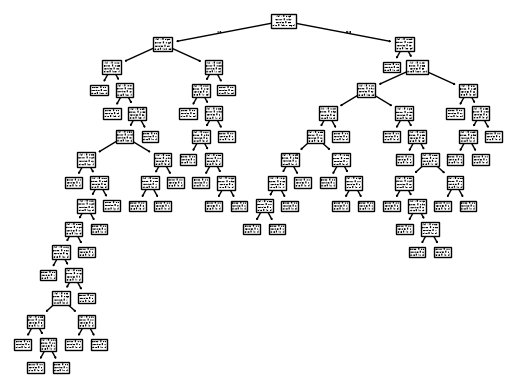

In [31]:
from sklearn import tree
tree.plot_tree(classifier)

In [32]:
# Gini model
classifier_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
classifier_gini.fit(X_train, y_train)

# Entropy model
classifier_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
classifier_entropy.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [33]:
# Predictions
y_pred_gini = classifier_gini.predict(X_test)
y_pred_entropy = classifier_entropy.predict(X_test)

# Accuracy
print("Gini Accuracy:", accuracy_score(y_test, y_pred_gini))
print("Entropy Accuracy:", accuracy_score(y_test, y_pred_entropy))

# Confusion matrix
print("Gini Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gini))
print("Entropy Confusion Matrix:\n", confusion_matrix(y_test, y_pred_entropy))

# Classification report
print("Gini Report:\n", classification_report(y_test, y_pred_gini))
print("Entropy Report:\n", classification_report(y_test, y_pred_entropy))

Gini Accuracy: 0.85
Entropy Accuracy: 0.85
Gini Confusion Matrix:
 [[56  7]
 [ 8 29]]
Entropy Confusion Matrix:
 [[56  7]
 [ 8 29]]
Gini Report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.88        63
           1       0.81      0.78      0.79        37

    accuracy                           0.85       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.85      0.85      0.85       100

Entropy Report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.88        63
           1       0.81      0.78      0.79        37

    accuracy                           0.85       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.85      0.85      0.85       100

